# Práctica: Tu primera Red Recurrente (RNN)
## Deep Learning Bootcamp

Vamos a entrenar una RNN para **análisis de sentimiento**: dada una reseña
de película (texto), la red decide si es **positiva** o **negativa**.

Usaremos el dataset **IMDB** (50.000 reseñas de cine) que viene integrado en Keras.

### Plan
1. Cargar y explorar las reseñas.
2. Entrenar con **SimpleRNN** y ver sus limitaciones.
3. Mejorar con **LSTM**.
4. Probar **GRU** y **Bidirectional**.
5. Comparar los cuatro modelos.



### Caracteristicas del Dataset:

Este dataset de Keras ya viene "pre-procesado" matemáticamente para que las redes neuronales puedan trabajar con él directamente. 

Cada palabra original fue reemplazada por un número según qué tan común es en todo el dataset. El número 4 podría significar "the", el 5 podría ser "and", el 6 "a", y así sucesivamente.

Existen 3 números "reservados" especiales en estas listas:
- 0: Sirve como relleno (padding). Lo usarás para estirar las reseñas cortas hasta llegar a 200 palabras.
- 1: Indica el inicio exacto de la reseña.
- 2: Indica una palabra desconocida (las que quedaron fuera de tu vocabulario).




> ℹ️ Activa la GPU en Colab: *Entorno de ejecución → Cambiar tipo → T4 GPU*.

## PASO 1 · Cargar IMDB

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print('TensorFlow', tf.__version__)

VOCAB = 10000    
MAX_LEN = 200     

(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB)
print('Train:', len(X_train), 'reseñas · Test:', len(X_test))
print('Ejemplo: primeras 10 palabras (como índices):', X_train[0][:10])
print('Etiqueta:', 'Positiva' if y_train[0]==1 else 'Negativa')

TensorFlow 2.21.0
Train: 25000 reseñas · Test: 25000
Ejemplo: primeras 10 palabras (como índices): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]
Etiqueta: Positiva


## PASO 2 · Ver una reseña real

In [2]:
word_index = keras.datasets.imdb.get_word_index()
reverse_index = {v+3: k for k, v in word_index.items()}
reverse_index[0] = '<PAD>'; reverse_index[1] = '<START>'
reverse_index[2] = '<UNK>'; reverse_index[3] = '<UNUSED>'

def decodificar(secuencia):
    return ' '.join(reverse_index.get(i, '?') for i in secuencia)

print('Reseña de ejemplo:')
print(decodificar(X_train[0])[:500], '...')
print('\nEtiqueta:', 'POSITIVA' if y_train[0]==1 else 'NEGATIVA')

Reseña de ejemplo:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would re ...

Etiqueta: POSITIVA


In [4]:
X_train.shape

(25000,)

## PASO 3 · Preparar los datos

Las reseñas tienen longitudes distintas. Las igualamos todas a `MAX_LEN`
(recortando las largas y rellenando las cortas con ceros).

In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post')
X_test  = pad_sequences(X_test, maxlen=MAX_LEN, padding='post')

print('Forma del train:', X_train.shape)  # (25000, 200)
print('Cada reseña es ahora un vector de', MAX_LEN, 'índices de palabras')

Forma del train: (25000, 200)
Cada reseña es ahora un vector de 200 índices de palabras


In [12]:
X_train.shape

(25000, 200)

## PASO 4 · Modelo 1: SimpleRNN

La arquitectura:
- **Embedding**: convierte cada índice de palabra en un vector de 64 números.
- **SimpleRNN**: lee la secuencia paso a paso, mantiene un estado oculto.
- **Dense + sigmoid**: clasifica en positivo (1) o negativo (0).

In [6]:
simple_rnn = keras.Sequential([
        keras.Input(shape=(MAX_LEN,)),
        layers.Embedding(VOCAB, 64),
        layers.SimpleRNN(64),
        layers.Dense(1, activation='sigmoid')
        ])

simple_rnn.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

simple_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
h_simple = simple_rnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1)

loss, acc = simple_rnn.evaluate(X_test, y_test, verbose=0)
print(f'\nSimpleRNN — Accuracy test: {acc:.2%}')

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - accuracy: 0.5138 - loss: 0.6918 - val_accuracy: 0.5386 - val_loss: 0.6855
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.6090 - loss: 0.6528 - val_accuracy: 0.5732 - val_loss: 0.8736
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.6662 - loss: 0.5680 - val_accuracy: 0.5252 - val_loss: 0.7191
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.7369 - loss: 0.4252 - val_accuracy: 0.5318 - val_loss: 0.8073
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.7620 - loss: 0.3829 - val_accuracy: 0.5324 - val_loss: 0.8355

SimpleRNN — Accuracy test: 52.57%


## PASO 5 · Modelo 2: LSTM

Mismo código, cambiando solo el tipo de capa.

In [8]:
lstm = keras.Sequential([
        keras.Input(shape=(MAX_LEN,)),
        layers.Embedding(VOCAB, 64),
        layers.LSTM(64),
        layers.Dense(1, activation='sigmoid')
        ])

lstm.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
h_lstm = lstm.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1)


loss, acc_lstm = lstm.evaluate(X_test, y_test, verbose=0)
print(f'\nLSTM — Accuracy test: {acc_lstm:.2%}')

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 248ms/step - accuracy: 0.5501 - loss: 0.6819 - val_accuracy: 0.6178 - val_loss: 0.6190
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 238ms/step - accuracy: 0.5999 - loss: 0.6569 - val_accuracy: 0.6134 - val_loss: 0.6455
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 238ms/step - accuracy: 0.7003 - loss: 0.5758 - val_accuracy: 0.7302 - val_loss: 0.5658
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 243ms/step - accuracy: 0.7090 - loss: 0.5663 - val_accuracy: 0.6586 - val_loss: 0.6186
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 241ms/step - accuracy: 0.7341 - loss: 0.5320 - val_accuracy: 0.7882 - val_loss: 0.4865

LSTM — Accuracy test: 80.03%


## PASO 6 · Modelo 3: GRU

In [10]:
gru = keras.Sequential([
        keras.Input(shape=(MAX_LEN,)),
        layers.Embedding(VOCAB, 64),
        layers.GRU(64),
        layers.Dense(1, activation='sigmoid')
        ])

gru.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,025 (2.54 MB)

 Trainable params: 665,025 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
h_gru = gru.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1)


loss, acc_gru = gru.evaluate(X_test, y_test, verbose=0)
print(f'\nGRU — Accuracy test: {acc_gru:.2%}')

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 46s 273ms/step - accuracy: 0.5517 - loss: 0.6787 - val_accuracy: 0.5848 - val_loss: 0.9683
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 248ms/step - accuracy: 0.6207 - loss: 0.6234 - val_accuracy: 0.6768 - val_loss: 0.5699
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 239ms/step - accuracy: 0.8001 - loss: 0.4466 - val_accuracy: 0.8500 - val_loss: 0.3841
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 243ms/step - accuracy: 0.8920 - loss: 0.2845 - val_accuracy: 0.8596 - val_loss: 0.3375
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 252ms/step - accuracy: 0.9273 - loss: 0.2030 - val_accuracy: 0.8780 - val_loss: 0.3113

GRU — Accuracy test: 87.24%


## PASO 7 · Modelo 4: LSTM Bidireccional

In [12]:
gru_bidireccional = keras.Sequential([
        keras.Input(shape=(MAX_LEN,)),
        layers.Embedding(VOCAB, 64),
        # GRU con Bidirectional
        layers.Bidirectional(layers.GRU(64)), 
        layers.Dense(1, activation='sigmoid')
        ])

gru_bidireccional.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

gru_bidireccional.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 690,049 (2.63 MB)

 Trainable params: 690,049 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
h_bi = gru_bidireccional.fit(X_train, y_train,
                            epochs=5,
                            batch_size=128,
                            validation_split=0.2,
                            verbose=1)


loss, acc_bi = gru_bidireccional.evaluate(X_test, y_test, verbose=0)
print(f'\nLSTM Bidireccional — Accuracy test: {acc_bi:.2%}')

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 112s 689ms/step - accuracy: 0.6155 - loss: 0.6449 - val_accuracy: 0.8200 - val_loss: 0.4120
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 94s 598ms/step - accuracy: 0.8591 - loss: 0.3388 - val_accuracy: 0.8548 - val_loss: 0.3561
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 94s 600ms/step - accuracy: 0.9122 - loss: 0.2316 - val_accuracy: 0.8530 - val_loss: 0.3722
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 96s 611ms/step - accuracy: 0.9409 - loss: 0.1665 - val_accuracy: 0.8410 - val_loss: 0.4355
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 96s 609ms/step - accuracy: 0.9579 - loss: 0.1283 - val_accuracy: 0.8408 - val_loss: 0.4408

LSTM Bidireccional — Accuracy test: 83.79%


## PASO 8 · Comparar los 4 modelos
LSTM y GRU suelen superar a SimpleRNN. Bidireccional da un empujón extra.

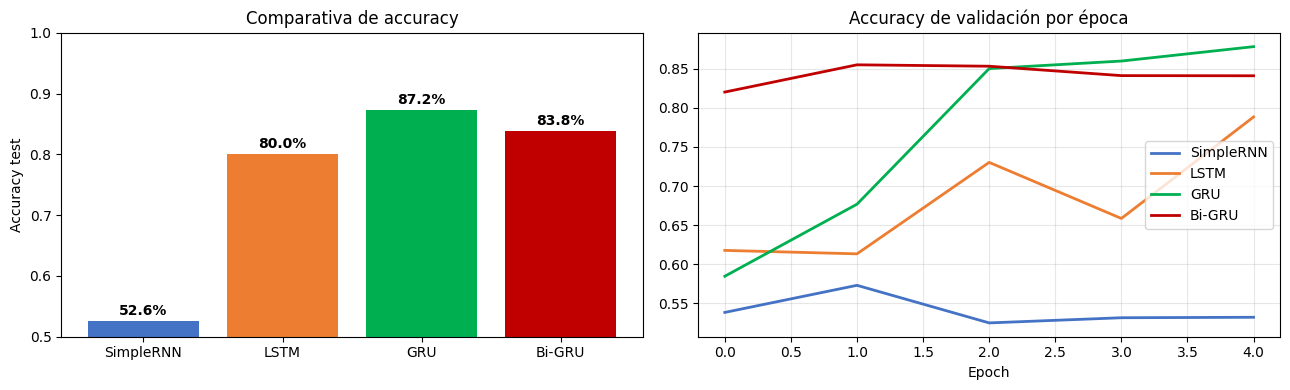

In [14]:
modelos = ['SimpleRNN', 'LSTM', 'GRU', 'Bi-GRU']
accs = [acc, acc_lstm, acc_gru, acc_bi]
colores = ['#4472C4', '#ED7D31', '#00B050', '#C00000']
historias = [h_simple, h_lstm, h_gru, h_bi]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(modelos, accs, color=colores)
axes[0].set_ylabel('Accuracy test'); axes[0].set_title('Comparativa de accuracy')
axes[0].set_ylim(0.5, 1.0)
for i, v in enumerate(accs):
    axes[0].text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')

for h, n, c in zip(historias, modelos, colores):
    axes[1].plot(h.history['val_accuracy'], label=n, linewidth=2, color=c)
axes[1].set_title('Accuracy de validación por época')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## PASO 9 · Predecir con tu propia reseña

In [15]:
def predecir_reseña(texto, modelo):
    tokens = texto.lower().split()
    indices = [word_index.get(w, 2)+3 for w in tokens]  # 2 = <UNK>
    indices = pad_sequences([indices], maxlen=MAX_LEN, padding='post')
    prob = modelo.predict(indices, verbose=0)[0][0]
    sentimiento = 'POSITIVA' if prob > 0.5 else 'NEGATIVA'
    print(f'  "{texto}"')
    print(f'  → {sentimiento} ({prob:.0%} positiva)\n')

print('Predicciones del modelo LSTM:\n')
predecir_reseña('this movie was amazing and wonderful', lstm)
predecir_reseña('terrible film, worst I have ever seen', lstm)
predecir_reseña('it was ok, nothing special', lstm)

Predicciones del modelo LSTM:

  "this movie was amazing and wonderful"
  → POSITIVA (76% positiva)

  "terrible film, worst I have ever seen"
  → NEGATIVA (13% positiva)

  "it was ok, nothing special"
  → NEGATIVA (13% positiva)

